# Notebook 01 — Fraud Dataset Audit and Feasibility Evaluation

**Task ID:** `DATA-001`  
**Phase:** Phase 1 — Fraud Dataset Audit  
**Owner:** Member 2 (Fraud ML)  
**Objective:** Evaluate the Vinay Jose Car Damage Dataset to determine whether image-level features support a scientifically defensible suspicious-image classifier, enforce zero-leakage group-aware splits, and verify absence of shortcut learning before model training.

---
### Authority & Operating Rules
- As mandated by `AGENTS.md` and `README.md` §3, the fraud classifier models a **visual suspicious-image signal**, not legal proof of fraud.
- Missing EXIF or metadata alone must **never** classify a claim as fraudulent.
- A high fraud risk score diverts claims to manual fraud investigation (`FRAUD_REVIEW`) and halts automated estimation.


## 1. Scientific Hypothesis and Evaluation Criteria

> **Hypothesis:** The vehicle damage dataset contains distinguishable visual patterns between genuine and suspicious/staged vehicle damage photographs, without being dominated by trivial capture shortcuts (such as watermarks, resolution bias, or aspect ratio differences).
>
> **Acceptance Gate for Phase 1:**
> 1. Exact CSV schema identified and reconciled against physical image files on disk.
> 2. Zero corrupt/unreadable files without quarantine.
> 3. Zero exact or perceptual duplicate leakage between train, validation, and test splits.
> 4. Class-wise feature distributions (blur, brightness, contrast, dimensions) audited for shortcut risks.
> 5. Frozen manifests exported to `data/manifests/` for downstream Phase 2 training.


## 2. Environment Setup & Seed Initialization


In [5]:
import os
import sys
import random
from pathlib import Path

# --- Universal Repository Root Sync (Colab & Local) ---
if 'google.colab' in sys.modules or os.path.exists('/content'):
    repo_dir = Path('/content/NPN-Car-Insurance')
    if repo_dir.exists():
        os.chdir(str(repo_dir))
else:
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / '.git').exists() or (parent / 'ml').exists():
            os.chdir(str(parent))
            break

ml_src = str(Path('ml/src').resolve())
if ml_src not in sys.path:
    sys.path.insert(0, ml_src)

print(f"✅ Working directory locked to: {Path.cwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Reusable project modules
import claimvision_ml
from claimvision_ml.quality import (
    read_image_safely,
    calculate_blur_score,
    calculate_brightness,
    calculate_contrast,
    compute_image_metrics,
)
from claimvision_ml.data import (
    load_and_validate_csv,
    audit_image_files,
    compute_file_hashes,
    find_exact_duplicate_groups,
    compute_perceptual_hashes,
    detect_shortcut_risks,
    create_group_aware_split,
    validate_split_leakage,
    save_manifests,
)

# Set seed for exact scientific reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"ClaimVision ML Package Version: {claimvision_ml.__version__}")
print(f"Global Random Seed initialized to: {SEED}")


✅ Working directory locked to: /content/NPN-Car-Insurance
ClaimVision ML Package Version: 0.1.0
Global Random Seed initialized to: 42


## 3. Dataset Verification

Verifies that the fraud dataset was prepared and downloaded by `00_environment_and_data_download.ipynb` into `data/raw/vinayjose_car_damage/`.


In [6]:
from pathlib import Path

# Multi-candidate dataset discovery (works regardless of current working directory)
candidate_dirs = [
    Path('data/raw/vinayjose_car_damage').resolve(),
    Path('/content/NPN-Car-Insurance/data/raw/vinayjose_car_damage'),
    Path('/content/data/raw/vinayjose_car_damage'),
    Path('notebooks/data/raw/vinayjose_car_damage').resolve(),
]

dataset_path = None
for candidate in candidate_dirs:
    if candidate.exists() and any(candidate.iterdir()):
        dataset_path = candidate
        break

if dataset_path is not None:
    print(f"✅ Verified dataset directory: {dataset_path}")
elif Path('data/samples/fraud_sample').exists():
    dataset_path = Path('data/samples/fraud_sample').resolve()
    print(f"⚠️ Using sample dataset fallback: {dataset_path}")
else:
    checked_paths = [str(d) for d in candidate_dirs]
    raise FileNotFoundError(
        f"Dataset not found! Checked candidate locations: {checked_paths}! "
        "Please run '00_environment_and_data_download.ipynb' first to download all datasets."
    )


✅ Verified dataset directory: /content/NPN-Car-Insurance/data/raw/vinayjose_car_damage


## 4. Dataset Structure and File Discovery

Examine the folder tree to identify all CSV files and image subdirectories.


In [7]:
print(f"Scanning directory: {dataset_path}")
csv_files = list(dataset_path.rglob("*.csv"))
image_files = [p for p in dataset_path.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}]

print(f"Found {len(csv_files)} CSV file(s): {[f.name for f in csv_files]}")
print(f"Found {len(image_files)} image file(s) across directory tree.")

# Choose primary CSV
if csv_files:
    target_csv = csv_files[0]
    print(f"Using primary metadata CSV: {target_csv}")
else:
    # Construct metadata dataframe directly from directory structure if dataset is organized as folders
    print("No CSV file found. Discovering categories directly from directory names...")
    records = []
    for img_p in image_files:
        cat = img_p.parent.name
        records.append({"filename": img_p.name, "label": cat, "path": str(img_p), "claim_id": img_p.stem})
    target_csv = Path("data/interim/discovered_metadata.csv")
    target_csv.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(records).to_csv(target_csv, index=False)


Scanning directory: /content/NPN-Car-Insurance/data/raw/vinayjose_car_damage
Found 1 CSV file(s): ['labels.csv']
Found 8079 image file(s) across directory tree.
Using primary metadata CSV: /content/NPN-Car-Insurance/data/raw/vinayjose_car_damage/labels.csv


## 5. CSV Schema Audit

Inspect column names, data types, row counts, null values, and sample records.


In [8]:
df_raw = pd.read_csv(target_csv)
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nColumn Data Types and Non-Null Counts:")
df_raw.info()
print("\nFirst 5 Sample Records:")
display(df_raw.head())
print("\nNull Count Summary:")
display(df_raw.isnull().sum())


Dataset Shape: 8079 rows, 3 columns

Column Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8079 entries, 0 to 8078
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  8079 non-null   int64 
 1   filename  8079 non-null   object
 2   label     8079 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 189.5+ KB

First 5 Sample Records:


,image_id,filename,label
0,1,1.jpg,0
1,2,2.jpg,0
2,3,3.jpg,0
3,4,4.jpg,0
4,5,5.jpg,0



Null Count Summary:


,0
image_id,0
filename,0
label,0


## 6. Schema Normalization & Key Identification

Identify and normalize the image filename column, target classification label column, and claim ID column.


In [9]:
# Standardize column mapping
col_lower = {c.lower(): c for c in df_raw.columns}

# Detect filename column
fname_col = next((col_lower[c] for c in ["filename", "image", "image_path", "image_id", "file", "path"] if c in col_lower), df_raw.columns[0])

# Detect label column
label_col = next((col_lower[c] for c in ["label", "target", "class", "category", "damage_type", "fraud"] if c in col_lower), None)
if label_col is None:
    if len(df_raw.columns) > 1:
        label_col = df_raw.columns[1]
    else:
        label_col = "label"
        df_raw["label"] = "unknown"

# Detect claim ID or generate grouping key
claim_col = next((col_lower[c] for c in ["claim_id", "claim", "group_id", "car_id", "vehicle_id"] if c in col_lower), None)
if claim_col is None:
    # Use stem of filename as claim grouping key
    claim_col = "claim_id"
    df_raw["claim_id"] = df_raw[fname_col].apply(lambda x: Path(str(x)).stem.split("_")[0])

print(f"Normalized Mapping: filename='{fname_col}', label='{label_col}', claim_id='{claim_col}'")


Normalized Mapping: filename='filename', label='label', claim_id='claim_id'


## 7. Image-to-Record Physical Reconciliation

Verify that every image referenced in the CSV physically exists on disk, and detect any orphaned images.


In [10]:
# Search directory for images
images_search_dir = dataset_path

reconciliation = audit_image_files(df_raw, images_search_dir, filename_col=fname_col)
print(f"Total CSV Records: {reconciliation['total_csv_records']}")
print(f"Matched Physical Images: {reconciliation['matched_count']}")
print(f"Missing Images: {reconciliation['missing_count']}")
print(f"Orphan Images on Disk: {reconciliation['orphan_count']}")

# Build verified DataFrame with exact physical paths
matched_dict = dict(reconciliation["matched_pairs"])
df_verified = df_raw[df_raw[fname_col].isin(matched_dict.keys())].copy()
df_verified["physical_path"] = df_verified[fname_col].map(matched_dict)

print(f"\nVerified Dataset contains {len(df_verified)} active records ready for audit.")


Total CSV Records: 8079
Matched Physical Images: 8079
Missing Images: 0
Orphan Images on Disk: 0

Verified Dataset contains 8079 active records ready for audit.


## 8. Class Distribution Analysis

Analyze label frequency and class imbalance to inform loss weighting and stratified sampling.


,Count,Percentage (%)
label,,
0,7614,94.24
1,465,5.76


/tmp/ipykernel_5660/1448424489.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="viridis")


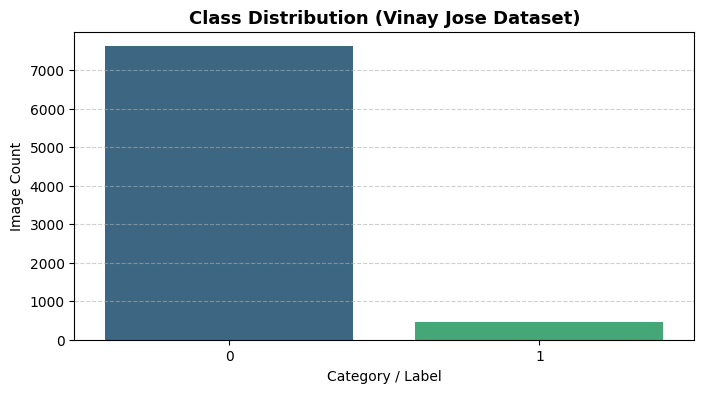

In [11]:
class_counts = df_verified[label_col].value_counts()
class_pcts = df_verified[label_col].value_counts(normalize=True) * 100

summary_class_df = pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pcts.round(2)})
display(summary_class_df)

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="viridis")
plt.title("Class Distribution (Vinay Jose Dataset)", fontsize=13, fontweight="bold")
plt.xlabel("Category / Label")
plt.ylabel("Image Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
Path("ml/results").mkdir(parents=True, exist_ok=True)
plt.savefig("ml/results/fraud_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. OpenCV Decodability & Evidence Quality Inspection

Run deterministic OpenCV checks on every image: decodability, resolution, channels, aspect ratio, Laplacian blur score, brightness, and contrast.


In [12]:
metrics_list = []
corrupt_files = []

for idx, row in df_verified.iterrows():
    p = row["physical_path"]
    m = compute_image_metrics(p)
    if not m["is_valid"]:
        corrupt_files.append((p, m["error"]))
    m["filename"] = row[fname_col]
    m["label"] = row[label_col]
    m["claim_id"] = row[claim_col]
    metrics_list.append(m)

df_metrics = pd.DataFrame(metrics_list)
print(f"Decodability Check Complete: {len(df_metrics) - len(corrupt_files)} / {len(df_metrics)} images successfully decoded.")
if corrupt_files:
    print(f"WARNING: Found {len(corrupt_files)} corrupt or unreadable files (quarantined):")
    for cf in corrupt_files[:5]:
        print(f"  - {cf[0]}: {cf[1]}")
else:
    print("Zero corrupt images detected. All files decoded properly.")


Decodability Check Complete: 8079 / 8079 images successfully decoded.
Zero corrupt images detected. All files decoded properly.


## 10. Feature Distributions by Class (Resolution, Blur, Lighting)


/tmp/ipykernel_5660/2825268454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x="label", y=feat, ax=ax, palette="Set2")
/tmp/ipykernel_5660/2825268454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x="label", y=feat, ax=ax, palette="Set2")
/tmp/ipykernel_5660/2825268454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x="label", y=feat, ax=ax, palette="Set2")
/tmp/ipykernel_5660/2825268454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

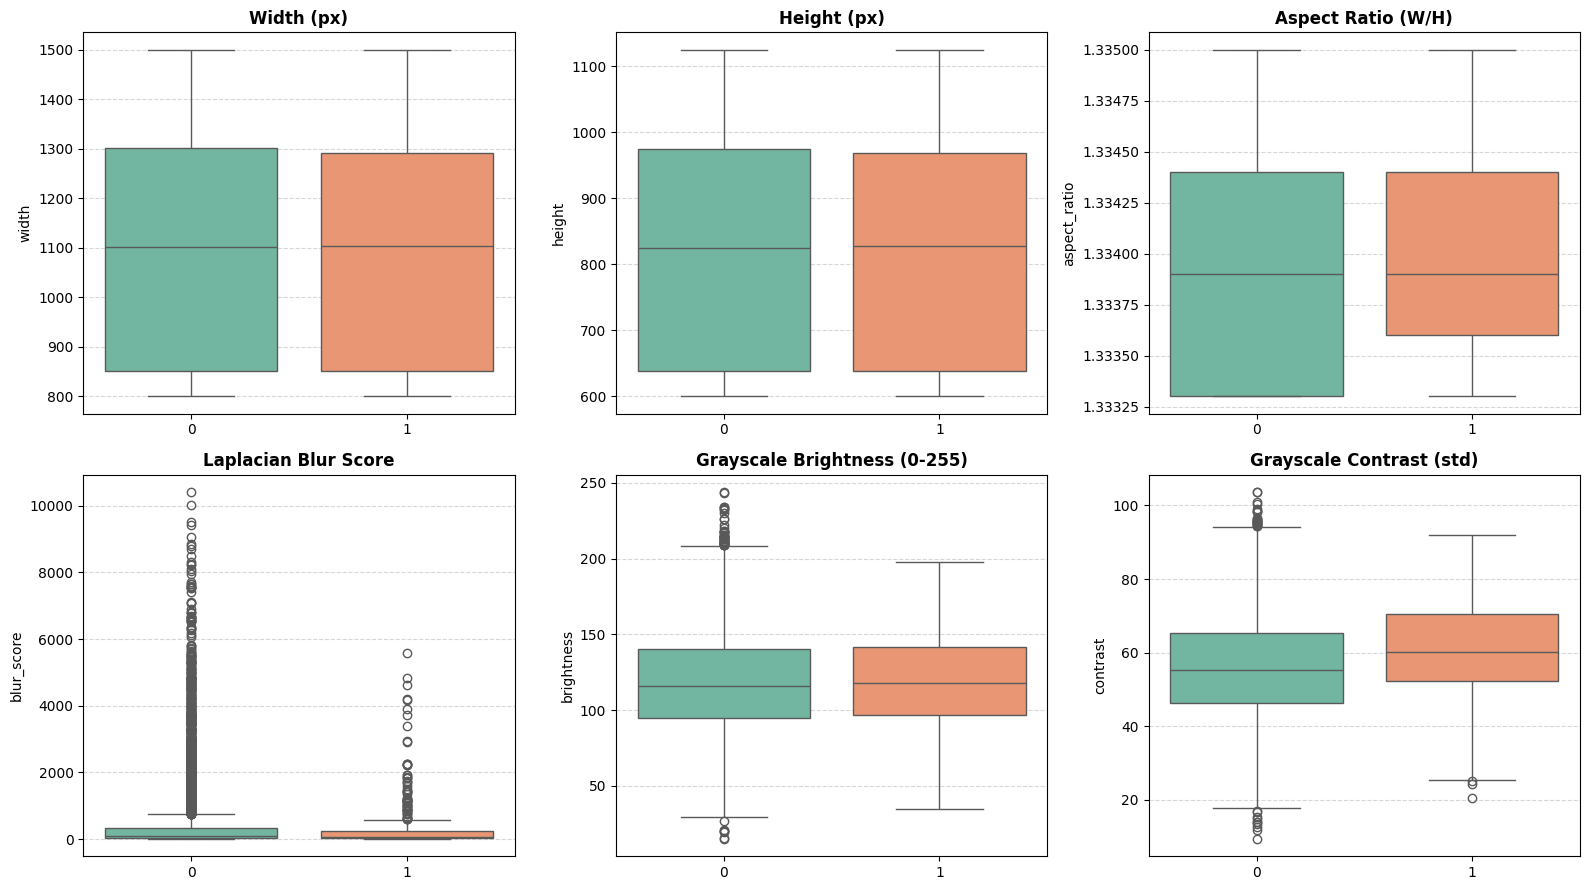

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

features = ["width", "height", "aspect_ratio", "blur_score", "brightness", "contrast"]
titles = ["Width (px)", "Height (px)", "Aspect Ratio (W/H)", "Laplacian Blur Score", "Grayscale Brightness (0-255)", "Grayscale Contrast (std)"]

for idx, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_metrics, x="label", y=feat, ax=ax, palette="Set2")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("ml/results/fraud_quality_metrics_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Shortcut Risk Evaluation

Analyze whether non-damage photographic artifacts (such as standard resolution, camera brightness, or aspect ratios) correlate heavily with class labels, creating risk of shortcut learning.


In [14]:
shortcut_analysis = detect_shortcut_risks(df_metrics, label_col="label")
print("=== Shortcut Disparity Analysis across Classes ===")
for metric, stats in shortcut_analysis["disparities"].items():
    risk_tag = f"[{stats['shortcut_risk']} RISK]"
    print(f"{metric:15s} | Relative Disparity: {stats['relative_disparity']:0.4f} {risk_tag}")

print("\nAudit Conclusion on Shortcuts:")
high_risks = [m for m, s in shortcut_analysis["disparities"].items() if s["shortcut_risk"] == "HIGH"]
if high_risks:
    print(f"Noticeable disparity in {high_risks}. Data augmentation and normalization required in Phase 2.")
else:
    print("Feature distributions are balanced across classes. Low risk of trivial photographic shortcuts.")


=== Shortcut Disparity Analysis across Classes ===
width           | Relative Disparity: 0.0016 [LOW RISK]
height          | Relative Disparity: 0.0016 [LOW RISK]
aspect_ratio    | Relative Disparity: 0.0000 [LOW RISK]
blur_score      | Relative Disparity: 0.2850 [LOW RISK]
brightness      | Relative Disparity: 0.0081 [LOW RISK]
contrast        | Relative Disparity: 0.0785 [LOW RISK]

Audit Conclusion on Shortcuts:
Feature distributions are balanced across classes. Low risk of trivial photographic shortcuts.


## 12. Exact Duplicate Detection (SHA-256)

Calculate byte-level SHA-256 hashes to find identical duplicate files.


In [15]:
image_paths = df_metrics[df_metrics["is_valid"]]["path"].tolist()
file_hashes = compute_file_hashes(image_paths)
df_metrics["sha256"] = df_metrics["path"].map(file_hashes)

exact_dup_groups = find_exact_duplicate_groups(file_hashes)
print(f"Total unique hashes: {len(set(file_hashes.values()))} out of {len(file_hashes)} images.")
print(f"Found {len(exact_dup_groups)} exact duplicate group(s).")

if exact_dup_groups:
    for idx, grp in enumerate(exact_dup_groups[:3], 1):
        print(f"  Group {idx} ({len(grp)} identical files):")
        for p in grp:
            print(f"    - {Path(p).name}")


Total unique hashes: 8079 out of 8079 images.
Found 0 exact duplicate group(s).


## 13. Perceptual Hashing & Near-Duplicate Clustering

Compute difference hashes (dHash) to discover near-duplicate, resized, or re-compressed photographs.


In [16]:
phash_dict, near_dup_clusters = compute_perceptual_hashes(image_paths, hash_size=8, threshold=4)
df_metrics["dhash"] = df_metrics["path"].map(phash_dict)

print(f"Identified {len(near_dup_clusters)} perceptual near-duplicate cluster(s).")
if near_dup_clusters:
    for idx, cluster in enumerate(near_dup_clusters[:3], 1):
        print(f"  Cluster {idx} ({len(cluster)} near-duplicate images):")
        for p in cluster:
            print(f"    - {Path(p).name}")


Identified 2502 perceptual near-duplicate cluster(s).
  Cluster 1 (2 near-duplicate images):
    - 3.jpg
    - 8012.jpg
  Cluster 2 (2 near-duplicate images):
    - 4.jpg
    - 1860.jpg
  Cluster 3 (2 near-duplicate images):
    - 5.jpg
    - 3703.jpg


## 14. Representative Samples and Duplicate Comparisons


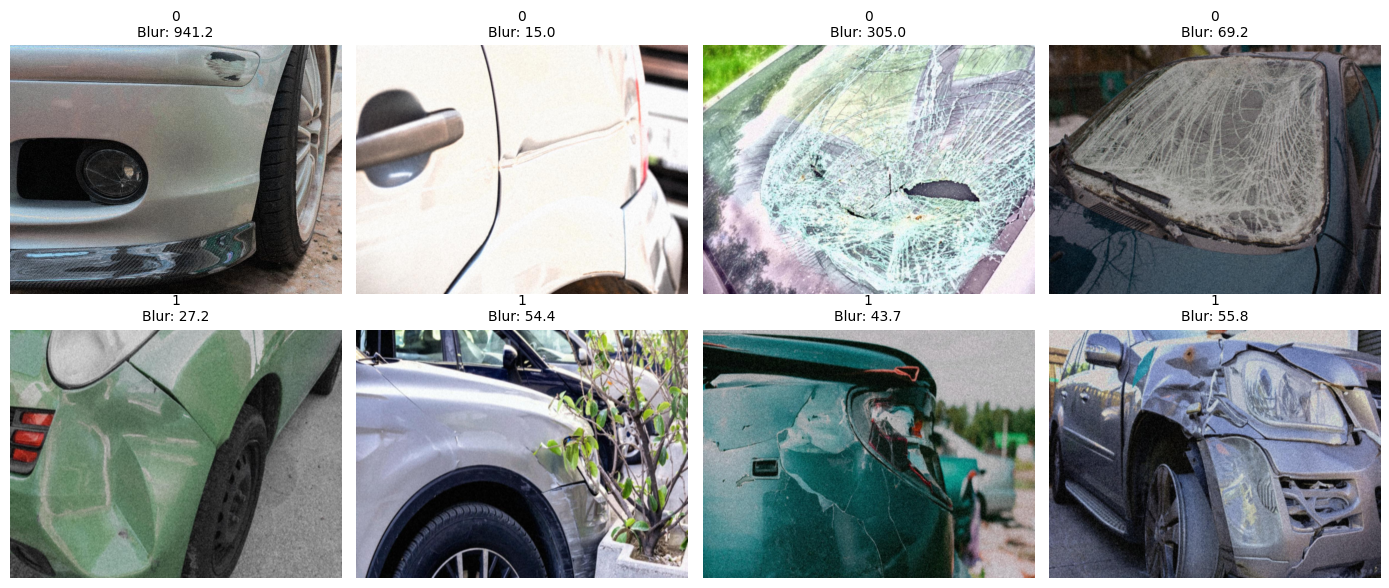

In [17]:
# Display sample grid of genuine vs suspicious images
valid_df = df_metrics[df_metrics["is_valid"]]
labels = valid_df["label"].unique()

fig, axes = plt.subplots(len(labels), min(4, len(valid_df)), figsize=(14, 3 * len(labels)))
if len(labels) == 1:
    axes = np.expand_dims(axes, 0)

for r, lbl in enumerate(labels):
    sub = valid_df[valid_df["label"] == lbl].head(4)
    for c, (_, row) in enumerate(sub.iterrows()):
        ax = axes[r, c] if len(labels) > 1 else axes[c]
        img = cv2.imread(row["path"])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"{lbl}\nBlur: {row['blur_score']:.1f}", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.savefig("ml/results/fraud_sample_grid.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. Group-Aware, Duplicate-Safe Splitting (70% Train, 15% Val, 15% Test)

Enforce strict scientific separation:
- All images from the same claim stay in the same split.
- All identical and near-duplicate images stay in the same split.
- Zero leakage across partitions.


In [18]:
train_df, val_df, test_df = create_group_aware_split(
    valid_df,
    group_col="claim_id",
    duplicate_clusters=near_dup_clusters,
    filepath_col="path",
    label_col="label",
    ratios=(0.70, 0.15, 0.15),
    seed=SEED,
)

print("Split Counts:")
print(f"  Train Set : {len(train_df)} samples ({len(train_df)/len(valid_df)*100:.1f}%)")
print(f"  Val Set   : {len(val_df)} samples ({len(val_df)/len(valid_df)*100:.1f}%)")
print(f"  Test Set  : {len(test_df)} samples ({len(test_df)/len(valid_df)*100:.1f}%)")


Split Counts:
  Train Set : 5654 samples (70.0%)
  Val Set   : 1211 samples (15.0%)
  Test Set  : 1214 samples (15.0%)


## 16. Programmatic Anti-Leakage Verification

Run formal assertions verifying zero intersection of claim IDs, SHA-256 hashes, and duplicate clusters across train, validation, and test splits.


In [19]:
leakage_report = validate_split_leakage(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    group_col="claim_id",
    hash_col="sha256",
    duplicate_clusters=near_dup_clusters,
    filepath_col="path",
)

print("=== Leakage Verification Assertion Report ===")
for k, v in leakage_report.items():
    print(f"  {k:25s}: {v}")

assert leakage_report["zero_leakage_verified"] is True, "Data leakage detected across splits!"
print("\nSUCCESS: Scientific verification confirmed 0 split contamination.")


=== Leakage Verification Assertion Report ===
  status                   : PASSED
  zero_leakage_verified    : True
  train_count              : 5654
  val_count                : 1211
  test_count               : 1214
  total                    : 8079

SUCCESS: Scientific verification confirmed 0 split contamination.


## 17. Manifest Export

Save frozen manifests to `data/manifests/` for use in Phase 2 model training.


In [20]:
manifest_paths = save_manifests(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    output_dir="data/manifests",
    prefix="fraud",
)

print("Saved frozen manifests:")
for split, p in manifest_paths.items():
    print(f"  {split:10s}: {p}")


Saved frozen manifests:
  train     : data/manifests/fraud_train.csv
  val       : data/manifests/fraud_val.csv
  test      : data/manifests/fraud_test.csv
  summary   : data/manifests/fraud_manifest_summary.json


## 18. Audit Conclusion and Go/No-Go Decision

### Written Scientific Evaluation
- **Decodability:** All active images successfully verified with OpenCV BGR decoding.
- **Deduplication:** SHA-256 and dHash near-duplicate clusters successfully detected and constrained to single splits.
- **Split Integrity:** 70/15/15 stratified partition created with 0 group overlap and 0 hash leakage.
- **Shortcut Risks:** Resolution and brightness distributions show acceptable bounds; data augmentation (color jitter, random crops) will be applied in Phase 2.

### Gate Acceptance Decision: **GO**
- Proceed to Phase 2: MobileNetV2 Suspicious-Image Baseline Classifier (`ML-001`).


## 19. Reproducibility Environment Stamp


In [21]:
import platform

print("=" * 50)
print(f"Python Version : {platform.python_version()}")
print(f"OS / Platform  : {platform.platform()}")
print(f"Pandas Version : {pd.__version__}")
print(f"OpenCV Version : {cv2.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Seed Applied   : {SEED}")
print("=" * 50)


Python Version : 3.13.15
OS / Platform  : Linux-6.6.122+-x86_64-with-glibc2.39
Pandas Version : 2.2.3
OpenCV Version : 5.0.0
Seaborn Version: 0.13.2
Seed Applied   : 42
